In [1]:
import pandas as pd
import numpy as np

# 数据路径
DATA_DIR = '/home/user2/jzhang_data/Dissertation/data/'
SMRI_FILE = DATA_DIR + 'ukb_brain_mri_data.csv'

#---------------------------------------#
#--------------load sMRI----------------#
#---------------------------------------#
# 定义需要提取的sMRI Field IDs
smri_field_ids = [
    25888, 25889, 25822, 25823, 25892, 25880, 25881, 25864, 25865, 25838,
    25839, 25840, 25841, 25900, 25902, 25901, 25903, 25905, 25904, 25844,
    25845, 25830, 25831, 25862, 25863, 25846, 25847, 25782, 25783, 25870,
    25871, 25886, 25887, 25893, 25894, 25915, 25917, 25916, 25792, 25793,
    25790, 25791, 25808, 25809, 25810, 25811, 25812, 25813, 25784, 25785,
    25828, 25829, 25832, 25833, 25826, 25827, 25824, 25825, 25852, 25853,
    25788, 25789, 25802, 25803, 25804, 25805, 25806, 25807, 25860, 25861,
    25876, 25877, 25884, 25885, 25836, 25837, 25848, 25849, 25850, 25851,
    25866, 25867, 25868, 25869, 25872, 25873, 25814, 25815, 25794, 25795,
    25842, 25843, 25882, 25883, 25834, 25835, 25786, 25787, 25816, 25817,
    25798, 25799, 25800, 25801, 25874, 25875, 25818, 25819, 25820, 25821,
    25854, 25855, 25856, 25857, 25858, 25859, 25796, 25797, 25878, 25879,
    25895, 25896, 25897, 25899, 25898, 25909, 25911, 25910, 25912, 25914,
    25913, 25906, 25908, 25907, 25890, 25891, 25918, 25919, 25920
]

# 读取完整的MRI数据
ukbb_full = pd.read_csv(SMRI_FILE)

# 构建需要保留的列名（eid + sMRI字段的所有实例）
cols_to_keep = ['eid']

for field_id in smri_field_ids:
    # 查找所有包含该field_id的列（可能有-0.0, -2.0等不同实例）
    matching_cols = [col for col in ukbb_full.columns if col.startswith(f'{field_id}-')]
    cols_to_keep.extend(matching_cols)

# 只保留eid和sMRI相关列
ukbb_sMRI = ukbb_full[cols_to_keep].copy()

# 排除第三次随访数据（-3.0）
ukbb_sMRI = ukbb_sMRI.loc[:, ~ukbb_sMRI.columns.str.contains('-3.0')]

# 将eid设为索引
ukbb_sMRI.index = pd.Index(ukbb_sMRI['eid'])
ukbb_sMRI = ukbb_sMRI.drop(columns='eid')

# 删除包含缺失值的行
ukbb_sMRI = ukbb_sMRI.dropna()

#---------------------------------------#
#-----------brain region label----------#
#---------------------------------------#
# 脑区描述字典
brain_regions = {
    25888: "Amygdala (left)",
    25889: "Amygdala (right)",
    25822: "Angular Gyrus (left)",
    25823: "Angular Gyrus (right)",
    25892: "Brain-Stem",
    25880: "Caudate (left)",
    25881: "Caudate (right)",
    25864: "Central Opercular Cortex (left)",
    25865: "Central Opercular Cortex (right)",
    25838: "Cingulate Gyrus, anterior division (left)",
    25839: "Cingulate Gyrus, anterior division (right)",
    25840: "Cingulate Gyrus, posterior division (left)",
    25841: "Cingulate Gyrus, posterior division (right)",
    25900: "Crus I Cerebellum (left)",
    25902: "Crus I Cerebellum (right)",
    25901: "Crus I Cerebellum (vermis)",
    25903: "Crus II Cerebellum (left)",
    25905: "Crus II Cerebellum (right)",
    25904: "Crus II Cerebellum (vermis)",
    25844: "Cuneal Cortex (left)",
    25845: "Cuneal Cortex (right)",
    25830: "Frontal Medial Cortex (left)",
    25831: "Frontal Medial Cortex (right)",
    25862: "Frontal Operculum Cortex (left)",
    25863: "Frontal Operculum Cortex (right)",
    25846: "Frontal Orbital Cortex (left)",
    25847: "Frontal Orbital Cortex (right)",
    25782: "Frontal Pole (left)",
    25783: "Frontal Pole (right)",
    25870: "Heschl's Gyrus (includes H1 and H2) (left)",
    25871: "Heschl's Gyrus (includes H1 and H2) (right)",
    25886: "Hippocampus (left)",
    25887: "Hippocampus (right)",
    25893: "I-IV Cerebellum (left)",
    25894: "I-IV Cerebellum (right)",
    25915: "IX Cerebellum (left)",
    25917: "IX Cerebellum (right)",
    25916: "IX Cerebellum (vermis)",
    25792: "Inferior Frontal Gyrus, pars opercularis (left)",
    25793: "Inferior Frontal Gyrus, pars opercularis (right)",
    25790: "Inferior Frontal Gyrus, pars triangularis (left)",
    25791: "Inferior Frontal Gyrus, pars triangularis (right)",
    25808: "Inferior Temporal Gyrus, anterior division (left)",
    25809: "Inferior Temporal Gyrus, anterior division (right)",
    25810: "Inferior Temporal Gyrus, posterior division (left)",
    25811: "Inferior Temporal Gyrus, posterior division (right)",
    25812: "Inferior Temporal Gyrus, temporooccipital part (left)",
    25813: "Inferior Temporal Gyrus, temporooccipital part (right)",
    25784: "Insular Cortex (left)",
    25785: "Insular Cortex (right)",
    25828: "Intracalcarine Cortex (left)",
    25829: "Intracalcarine Cortex (right)",
    25832: "Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex) (left)",
    25833: "Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex) (right)",
    25826: "Lateral Occipital Cortex, inferior division (left)",
    25827: "Lateral Occipital Cortex, inferior division (right)",
    25824: "Lateral Occipital Cortex, superior division (left)",
    25825: "Lateral Occipital Cortex, superior division (right)",
    25852: "Lingual Gyrus (left)",
    25853: "Lingual Gyrus (right)",
    25788: "Middle Frontal Gyrus (left)",
    25789: "Middle Frontal Gyrus (right)",
    25802: "Middle Temporal Gyrus, anterior division (left)",
    25803: "Middle Temporal Gyrus, anterior division (right)",
    25804: "Middle Temporal Gyrus, posterior division (left)",
    25805: "Middle Temporal Gyrus, posterior division (right)",
    25806: "Middle Temporal Gyrus, temporooccipital part (left)",
    25807: "Middle Temporal Gyrus, temporooccipital part (right)",
    25860: "Occipital Fusiform Gyrus (left)",
    25861: "Occipital Fusiform Gyrus (right)",
    25876: "Occipital Pole (left)",
    25877: "Occipital Pole (right)",
    25884: "Pallidum (left)",
    25885: "Pallidum (right)",
    25836: "Paracingulate Gyrus (left)",
    25837: "Paracingulate Gyrus (right)",
    25848: "Parahippocampal Gyrus, anterior division (left)",
    25849: "Parahippocampal Gyrus, anterior division (right)",
    25850: "Parahippocampal Gyrus, posterior division (left)",
    25851: "Parahippocampal Gyrus, posterior division (right)",
    25866: "Parietal Operculum Cortex (left)",
    25867: "Parietal Operculum Cortex (right)",
    25868: "Planum Polare (left)",
    25869: "Planum Polare (right)",
    25872: "Planum Temporale (left)",
    25873: "Planum Temporale (right)",
    25814: "Postcentral Gyrus (left)",
    25815: "Postcentral Gyrus (right)",
    25794: "Precentral Gyrus (left)",
    25795: "Precentral Gyrus (right)",
    25842: "Precuneous Cortex (left)",
    25843: "Precuneous Cortex (right)",
    25882: "Putamen (left)",
    25883: "Putamen (right)",
    25834: "Subcallosal Cortex (left)",
    25835: "Subcallosal Cortex (right)",
    25786: "Superior Frontal Gyrus (left)",
    25787: "Superior Frontal Gyrus (right)",
    25816: "Superior Parietal Lobule (left)",
    25817: "Superior Parietal Lobule (right)",
    25798: "Superior Temporal Gyrus, anterior division (left)",
    25799: "Superior Temporal Gyrus, anterior division (right)",
    25800: "Superior Temporal Gyrus, posterior division (left)",
    25801: "Superior Temporal Gyrus, posterior division (right)",
    25874: "Supracalcarine Cortex (left)",
    25875: "Supracalcarine Cortex (right)",
    25818: "Supramarginal Gyrus, anterior division (left)",
    25819: "Supramarginal Gyrus, anterior division (right)",
    25820: "Supramarginal Gyrus, posterior division (left)",
    25821: "Supramarginal Gyrus, posterior division (right)",
    25854: "Temporal Fusiform Cortex, anterior division (left)",
    25855: "Temporal Fusiform Cortex, anterior division (right)",
    25856: "Temporal Fusiform Cortex, posterior division (left)",
    25857: "Temporal Fusiform Cortex, posterior division (right)",
    25858: "Temporal Occipital Fusiform Cortex (left)",
    25859: "Temporal Occipital Fusiform Cortex (right)",
    25796: "Temporal Pole (left)",
    25797: "Temporal Pole (right)",
    25878: "Thalamus (left)",
    25879: "Thalamus (right)",
    25895: "V Cerebellum (left)",
    25896: "V Cerebellum (right)",
    25897: "VI Cerebellum (left)",
    25899: "VI Cerebellum (right)",
    25898: "VI Cerebellum (vermis)",
    25909: "VIIIa Cerebellum (left)",
    25911: "VIIIa Cerebellum (right)",
    25910: "VIIIa Cerebellum (vermis)",
    25912: "VIIIb Cerebellum (left)",
    25914: "VIIIb Cerebellum (right)",
    25913: "VIIIb Cerebellum (vermis)",
    25906: "VIIb Cerebellum (left)",
    25908: "VIIb Cerebellum (right)",
    25907: "VIIb Cerebellum (vermis)",
    25890: "Ventral Striatum (left)",
    25891: "Ventral Striatum (right)",
    25918: "X Cerebellum (left)",
    25919: "X Cerebellum (vermis)",
    25920: "X Cerebellum (right)"
}

# 创建DataFrame
descr_dict = pd.DataFrame(list(brain_regions.items()), columns=['id', 'name'])
descr_dict = descr_dict.sort_values('id').reset_index(drop=True)

# 提取脑区名称列表
sMRI_name = descr_dict['name'].to_list()

# 查看数据信息
print(f"sMRI数据形状: {ukbb_sMRI.shape}")
print(f"脑区数量: {len(sMRI_name)}")
print(f"提取的列数: {len(cols_to_keep)-1}")  # 减去eid
print(f"\n前10个提取的列名:")
print(cols_to_keep[1:11])

sMRI数据形状: (81870, 139)
脑区数量: 139
提取的列数: 139

前10个提取的列名:
['25888-2.0', '25889-2.0', '25822-2.0', '25823-2.0', '25892-2.0', '25880-2.0', '25881-2.0', '25864-2.0', '25865-2.0', '25838-2.0']


In [2]:
ukbb_sMRI.to_csv(r"/home/user2/jzhang_data/Dissertation/data/ukbb_sMRI_data.csv", index=True)

In [2]:
#---------------------------------------#
#--------------load dMRI----------------#
#---------------------------------------#
# 定义需要提取的dMRI Field IDs
dmri_field_ids = [
    25079, 25078, 25073, 25072, 25059, 25071, 25070, 25091, 25090, 25093,
    25092, 25063, 25062, 25089, 25088, 25095, 25094, 25061, 25058, 25067,
    25066, 25065, 25064, 25056, 25057, 25083, 25082, 25075, 25074, 25085,
    25084, 25077, 25076, 25087, 25086, 25060, 25069, 25068, 25081, 25080,
    25099, 25098, 25097, 25096, 25103, 25102, 25101, 25100
]

# 读取完整的MRI数据（与sMRI使用同一个文件）
ukbb_full = pd.read_csv(SMRI_FILE)

# 构建需要保留的列名（eid + dMRI字段的所有实例）
dmri_cols_to_keep = ['eid']

for field_id in dmri_field_ids:
    # 查找所有包含该field_id的列
    matching_cols = [col for col in ukbb_full.columns if col.startswith(f'{field_id}-')]
    dmri_cols_to_keep.extend(matching_cols)

# 只保留eid和dMRI相关列
ukbb_dMRI = ukbb_full[dmri_cols_to_keep].copy()

# 排除第三次随访数据（-3.0）
ukbb_dMRI = ukbb_dMRI.loc[:, ~ukbb_dMRI.columns.str.contains('-3.0')]

# 将eid设为索引
ukbb_dMRI.index = ukbb_dMRI['eid']
ukbb_dMRI = ukbb_dMRI.drop(columns='eid')

# 删除包含缺失值的行
ukbb_dMRI = ukbb_dMRI.dropna()

#---------------------------------------#
#-----------white matter tract label----#
#---------------------------------------#
# 白质纤维束描述字典
white_matter_tracts = {
    25079: "anterior corona radiata (left)",
    25078: "anterior corona radiata (right)",
    25073: "anterior limb of internal capsule (left)",
    25072: "anterior limb of internal capsule (right)",
    25059: "body of corpus callosum",
    25071: "cerebral peduncle (left)",
    25070: "cerebral peduncle (right)",
    25091: "cingulum cingulate gyrus (left)",
    25090: "cingulum cingulate gyrus (right)",
    25093: "cingulum hippocampus (left)",
    25092: "cingulum hippocampus (right)",
    25063: "corticospinal tract (left)",
    25062: "corticospinal tract (right)",
    25089: "external capsule (left)",
    25088: "external capsule (right)",
    25095: "fornix cres+stria terminalis (left)",
    25094: "fornix cres+stria terminalis (right)",
    25061: "fornix",
    25058: "genu of corpus callosum",
    25067: "inferior cerebellar peduncle (left)",
    25066: "inferior cerebellar peduncle (right)",
    25065: "medial lemniscus (left)",
    25064: "medial lemniscus (right)",
    25056: "middle cerebellar peduncle",
    25057: "pontine crossing tract",
    25083: "posterior corona radiata (left)",
    25082: "posterior corona radiata (right)",
    25075: "posterior limb of internal capsule (left)",
    25074: "posterior limb of internal capsule (right)",
    25085: "posterior thalamic radiation (left)",
    25084: "posterior thalamic radiation (right)",
    25077: "retrolenticular part of internal capsule (left)",
    25076: "retrolenticular part of internal capsule (right)",
    25087: "sagittal stratum (left)",
    25086: "sagittal stratum (right)",
    25060: "splenium of corpus callosum",
    25069: "superior cerebellar peduncle (left)",
    25068: "superior cerebellar peduncle (right)",
    25081: "superior corona radiata (left)",
    25080: "superior corona radiata (right)",
    25099: "superior fronto-occipital fasciculus (left)",
    25098: "superior fronto-occipital fasciculus (right)",
    25097: "superior longitudinal fasciculus (left)",
    25096: "superior longitudinal fasciculus (right)",
    25103: "tapetum (left)",
    25102: "tapetum (right)",
    25101: "uncinate fasciculus (left)",
    25100: "uncinate fasciculus (right)"
}

# 创建DataFrame
dMRI_descr_dict = pd.DataFrame(list(white_matter_tracts.items()), columns=['id', 'name'])
dMRI_descr_dict = dMRI_descr_dict.sort_values('id').reset_index(drop=True)

# 提取白质纤维束名称列表
dMRI_name = dMRI_descr_dict['name'].to_list()

# 查看数据信息
print(f"\ndMRI数据形状: {ukbb_dMRI.shape}")
print(f"白质纤维束数量: {len(dMRI_name)}")
print(f"提取的dMRI列数: {len(dmri_cols_to_keep)-1}")
print(f"\n前5个白质纤维束: {dMRI_name[:5]}")


dMRI数据形状: (79152, 48)
白质纤维束数量: 48
提取的dMRI列数: 48

前5个白质纤维束: ['middle cerebellar peduncle', 'pontine crossing tract', 'genu of corpus callosum', 'body of corpus callosum', 'splenium of corpus callosum']


In [4]:
ukbb_dMRI.to_csv(r"/home/user2/jzhang_data/Dissertation/data/ukbb_dMRI_data.csv", index=True)

In [3]:
#---------------------------------------#
#--------------load rfMRI----------------#
#---------------------------------------#
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import sys

# 强制刷新print输出
def print_flush(msg):
    print(msg)
    sys.stdout.flush()

# rfMRI数据路径
RFMRI_DIR = r"/home/user2/jzhang_data/Dissertation/data/opt/notebooks/rfMRI/"
rfmri_pattern = "*_25752_2_0.txt"

print_flush("="*60)
print_flush("开始加载rfMRI数据")
print_flush("="*60)

# UK Biobank官方定义的21个有效ICA成分
good_components = [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
n_networks = len(good_components)  # 21个有效成分
TAR_ITEMS_PER_SUB = 210  # 21 * (21 - 1) / 2 = 210个偏相关系数

print_flush(f"\n有效ICA成分数: {n_networks}")
print_flush(f"期望连接数: {TAR_ITEMS_PER_SUB}")

# 查找所有rfMRI文件
print_flush(f"\n正在搜索文件: {os.path.join(RFMRI_DIR, rfmri_pattern)}")
rfmri_files = glob.glob(os.path.join(RFMRI_DIR, rfmri_pattern))
print_flush(f"✓ 找到 {len(rfmri_files)} 个rfMRI文件")

if len(rfmri_files) == 0:
    print_flush(f"错误: 未找到任何文件！")
    print_flush(f"请检查路径是否正确: {RFMRI_DIR}")
    sys.exit(1)

# 生成连接名称
print_flush("\n正在生成连接名称...")
rfMRI_connection_names = []
for i in range(len(good_components)):
    for j in range(i+1, len(good_components)):
        comp_i = good_components[i]
        comp_j = good_components[j]
        rfMRI_connection_names.append(f"ICA_{comp_i}_ICA_{comp_j}")

print_flush(f"✓ 生成了 {len(rfMRI_connection_names)} 个连接名称")

# 验证连接数
assert len(rfMRI_connection_names) == TAR_ITEMS_PER_SUB, \
    f"连接数不匹配: 期望{TAR_ITEMS_PER_SUB}, 实际{len(rfMRI_connection_names)}"

# 读取所有被试的rfMRI数据
print_flush("\n开始读取文件...")
rfmri_data = {}
skipped_files = []
error_files = []

# 每处理1000个文件输出一次进度
batch_size = 1000

for idx, file_path in enumerate(rfmri_files):
    try:
        # 从文件名提取eid
        filename = os.path.basename(file_path)
        eid = filename.split('_')[0]
        
        # 读取文件内容
        with open(file_path, 'r') as f:
            content = f.read().strip()
            values = [float(x) for x in content.split()]
        
        # 验证数据长度
        if len(values) != TAR_ITEMS_PER_SUB:
            skipped_files.append((filename, len(values)))
            continue
        
        # 保存数据
        rfmri_data[eid] = values
        
        # 每处理batch_size个文件输出进度
        if (idx + 1) % batch_size == 0:
            print_flush(f"  已处理: {idx+1}/{len(rfmri_files)} ({(idx+1)/len(rfmri_files)*100:.1f}%) | 成功: {len(rfmri_data)} | 跳过: {len(skipped_files)}")
        
    except Exception as e:
        error_files.append((filename, str(e)))
        if len(error_files) <= 5:  # 只输出前5个错误
            print_flush(f"  错误: {filename} - {e}")
        continue

# 最终进度
print_flush(f"  已处理: {len(rfmri_files)}/{len(rfmri_files)} (100.0%) | 成功: {len(rfmri_data)} | 跳过: {len(skipped_files)}")

# 转换为DataFrame
print_flush("\n正在创建DataFrame...")
ukbb_rfMRI = pd.DataFrame.from_dict(rfmri_data, orient='index', columns=rfMRI_connection_names)
ukbb_rfMRI.index.name = 'eid'
print_flush(f"✓ DataFrame创建完成: {ukbb_rfMRI.shape}")

# 转换eid为整数
print_flush("\n正在转换eid为整数...")
ukbb_rfMRI.index = ukbb_rfMRI.index.astype(int)
print_flush("✓ eid转换完成")

# 删除包含缺失值的行
rows_before = len(ukbb_rfMRI)
print_flush(f"\n检查缺失值...")
print_flush(f"  删除前: {rows_before} 行")
ukbb_rfMRI = ukbb_rfMRI.dropna()
rows_after = len(ukbb_rfMRI)
print_flush(f"  删除后: {rows_after} 行")
if rows_before > rows_after:
    print_flush(f"  删除了 {rows_before - rows_after} 行包含缺失值的数据")

# 输出详细统计
print_flush("\n" + "="*60)
print_flush("rfMRI数据加载完成")
print_flush("="*60)
print_flush(f"总文件数: {len(rfmri_files)}")
print_flush(f"成功加载: {len(rfmri_data)}")
print_flush(f"跳过文件: {len(skipped_files)}")
print_flush(f"错误文件: {len(error_files)}")

if len(skipped_files) > 0:
    print_flush(f"\n跳过文件详情 (前5个):")
    for fname, n_vals in skipped_files[:5]:
        print_flush(f"  {fname}: {n_vals}个值 (期望{TAR_ITEMS_PER_SUB})")

if len(error_files) > 0:
    print_flush(f"\n错误文件详情 (前5个):")
    for fname, err in error_files[:5]:
        print_flush(f"  {fname}: {err}")

print_flush(f"\n最终数据形状: {ukbb_rfMRI.shape}")
print_flush(f"  被试数: {ukbb_rfMRI.shape[0]}")
print_flush(f"  连接数: {ukbb_rfMRI.shape[1]}")

# 验证
assert ukbb_rfMRI.shape[1] == TAR_ITEMS_PER_SUB, \
    f"特征数不匹配: 期望{TAR_ITEMS_PER_SUB}, 实际{ukbb_rfMRI.shape[1]}"

print_flush(f"\n前10个连接:")
for i in range(min(10, len(rfMRI_connection_names))):
    print_flush(f"  {i+1:3d}. {rfMRI_connection_names[i]}")

print_flush(f"\n数据预览:")
print_flush(ukbb_rfMRI.head().to_string())

# 数据统计
print_flush(f"\n数据统计:")
print_flush(f"  偏相关系数范围: [{ukbb_rfMRI.values.min():.4f}, {ukbb_rfMRI.values.max():.4f}]")
print_flush(f"  整体平均值: {ukbb_rfMRI.values.mean():.4f}")
print_flush(f"  整体标准差: {ukbb_rfMRI.values.std():.4f}")
print_flush(f"  整体中位数: {np.median(ukbb_rfMRI.values):.4f}")

# 检查数据分布
print_flush(f"\n偏相关系数分布:")
n_total = ukbb_rfMRI.size
print_flush(f"  < -0.5: {(ukbb_rfMRI.values < -0.5).sum():,} ({(ukbb_rfMRI.values < -0.5).sum()/n_total*100:.2f}%)")
print_flush(f"  -0.5~0: {((ukbb_rfMRI.values >= -0.5) & (ukbb_rfMRI.values < 0)).sum():,} ({((ukbb_rfMRI.values >= -0.5) & (ukbb_rfMRI.values < 0)).sum()/n_total*100:.2f}%)")
print_flush(f"  0~0.5:  {((ukbb_rfMRI.values >= 0) & (ukbb_rfMRI.values < 0.5)).sum():,} ({((ukbb_rfMRI.values >= 0) & (ukbb_rfMRI.values < 0.5)).sum()/n_total*100:.2f}%)")
print_flush(f"  >= 0.5: {(ukbb_rfMRI.values >= 0.5).sum():,} ({(ukbb_rfMRI.values >= 0.5).sum()/n_total*100:.2f}%)")

print_flush(f"\n✓ 所有处理完成!")
print_flush("="*60)

开始加载rfMRI数据

有效ICA成分数: 21
期望连接数: 210

正在搜索文件: /home/user2/jzhang_data/Dissertation/data/opt/notebooks/rfMRI/*_25752_2_0.txt
✓ 找到 79344 个rfMRI文件

正在生成连接名称...
✓ 生成了 210 个连接名称

开始读取文件...
  已处理: 1000/79344 (1.3%) | 成功: 1000 | 跳过: 0
  已处理: 2000/79344 (2.5%) | 成功: 2000 | 跳过: 0
  已处理: 3000/79344 (3.8%) | 成功: 3000 | 跳过: 0
  已处理: 4000/79344 (5.0%) | 成功: 4000 | 跳过: 0
  已处理: 5000/79344 (6.3%) | 成功: 5000 | 跳过: 0
  已处理: 6000/79344 (7.6%) | 成功: 6000 | 跳过: 0
  已处理: 7000/79344 (8.8%) | 成功: 7000 | 跳过: 0
  已处理: 8000/79344 (10.1%) | 成功: 8000 | 跳过: 0
  已处理: 9000/79344 (11.3%) | 成功: 9000 | 跳过: 0
  已处理: 10000/79344 (12.6%) | 成功: 10000 | 跳过: 0
  已处理: 11000/79344 (13.9%) | 成功: 11000 | 跳过: 0
  已处理: 12000/79344 (15.1%) | 成功: 12000 | 跳过: 0
  已处理: 13000/79344 (16.4%) | 成功: 13000 | 跳过: 0
  已处理: 14000/79344 (17.6%) | 成功: 14000 | 跳过: 0
  已处理: 15000/79344 (18.9%) | 成功: 15000 | 跳过: 0
  已处理: 16000/79344 (20.2%) | 成功: 16000 | 跳过: 0
  已处理: 17000/79344 (21.4%) | 成功: 17000 | 跳过: 0
  已处理: 18000/79344 (22.7%) | 成功: 18000 | 跳

In [6]:
ukbb_rfMRI.to_csv(r"/home/user2/jzhang_data/Dissertation/data/ukbb_rfMRI_data.csv", index=True)

In [4]:
#######################################################
#          DECONFOUNDING THE BRAIN DATA               #
#######################################################
def deconf(X, subj_index):
    # deconfound the brain space once - behavior one-by-one later
    from nilearn.signal import clean
    from sklearn.preprocessing import StandardScaler
    
    sc = StandardScaler()
    X = sc.fit_transform(X)

    con_subj = subj_index.to_list()

    beh = pd.read_csv(DATA_DIR+'ukb_brain_mri_covariate.csv')
    beh.index = beh['eid']
    beh = beh.drop(columns='eid')
    beh = beh.loc[con_subj]


    # Mean rfMRI head motion
    head_motion_rest = np.nan_to_num(
        beh['25741-2.0'].values
    )
    # Mean tfMRI head motion
    head_motion_task = np.nan_to_num(
        beh['25742-2.0'].values
    )
    # Volume of grey matter
    head_size = np.nan_to_num(
        beh['25006-2.0'].values
    )

    # motivated by Elliott et al., 2018
    # exact location of the head and the radio-frequency
    # receiver coil in the scanner
    head_pos_x = np.nan_to_num(
        beh['25756-2.0'].values 
    )
    head_pos_y = np.nan_to_num(
        beh['25757-2.0'].values
    )
    head_pos_z = np.nan_to_num(
        beh['25758-2.0'].values
    )
    head_pos_table = np.nan_to_num(
        beh['25759-2.0'].values
    )
    scan_site_dummies = pd.get_dummies(
        beh['54-2.0']
    ).values

    assert not np.any(np.isnan(head_motion_rest))
    assert not np.any(np.isnan(head_motion_task))
    assert not np.any(np.isnan(head_size))

    print('Deconfounding brain feature space!')
    conf_mat = np.hstack([
        np.atleast_2d(head_motion_rest).T, np.atleast_2d(head_motion_task).T,
        np.atleast_2d(head_size).T, 
        np.atleast_2d(head_pos_x).T, np.atleast_2d(head_pos_y).T,
        np.atleast_2d(head_pos_z).T, np.atleast_2d(head_pos_table).T,
        np.atleast_2d(scan_site_dummies)
        ])

    print(len(X))
    print(len(conf_mat))
    X = clean(X, confounds=conf_mat, detrend=False, standardize=False)
    return X

In [6]:
##### sMRI deconfound ########
import nilearn

X = deconf(ukbb_sMRI.values, ukbb_sMRI.index)
df_input_sMRI = pd.DataFrame(X, index=ukbb_sMRI.index, columns=sMRI_name)
df_input_sMRI.to_csv(DATA_DIR + 'ukbb_sMRI_deconfounded.csv', index=True)
print(f"✓ sMRI去混淆完成: {df_input_sMRI.shape}")

Deconfounding brain feature space!
81870
81870


/tmp/ipykernel_197973/1937849334.py:67: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  X = clean(X, confounds=conf_mat, detrend=False, standardize=False)
/tmp/ipykernel_197973/1937849334.py:67: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  X = clean(X, confounds=conf_mat, detrend=False, standardize=False)


✓ sMRI去混淆完成: (81870, 139)


In [7]:
##### dMRI  deconfound ########
X = deconf(ukbb_dMRI.values, ukbb_dMRI.index)
df_input_dMRI = pd.DataFrame(X, index=ukbb_dMRI.index, columns=dMRI_name)
df_input_dMRI.to_csv(DATA_DIR + 'ukbb_dMRI_deconfounded.csv', index=True)
print(f"✓ dMRI去混淆完成: {df_input_dMRI.shape}")

Deconfounding brain feature space!
79152
79152


/tmp/ipykernel_197973/1937849334.py:67: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  X = clean(X, confounds=conf_mat, detrend=False, standardize=False)
/tmp/ipykernel_197973/1937849334.py:67: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  X = clean(X, confounds=conf_mat, detrend=False, standardize=False)


✓ dMRI去混淆完成: (79152, 48)


In [8]:
##### rfMRI deconfound ########
X = deconf(ukbb_rfMRI.values, ukbb_rfMRI.index)
df_input_rfMRI = pd.DataFrame(X, index=ukbb_rfMRI.index, columns=rfMRI_connection_names)
df_input_rfMRI.to_csv(DATA_DIR + 'ukbb_rfMRI_deconfounded.csv', index=True)
print(f"✓ rfMRI去混淆完成: {df_input_rfMRI.shape}")

Deconfounding brain feature space!
79344
79344


/tmp/ipykernel_197973/1937849334.py:67: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  X = clean(X, confounds=conf_mat, detrend=False, standardize=False)
/tmp/ipykernel_197973/1937849334.py:67: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  X = clean(X, confounds=conf_mat, detrend=False, standardize=False)


✓ rfMRI去混淆完成: (79344, 210)


In [5]:
# 导入表型数据
import pandas as pd
import numpy as np
DATA_DIR = '/home/user2/jzhang_data/Dissertation/data/'

df_pa_obesity = pd.read_csv('/home/user2/jzhang_data/Dissertation/data/ukb_pa_obesity_processed.csv', index_col='eid')
print(f"✓ 数据加载完成: {df_pa_obesity.shape}")
print(f"\n列名:\n{df_pa_obesity.columns.tolist()}")
print(f"\n数据预览:\n{df_pa_obesity.head()}")

✓ 数据加载完成: (36929, 9)

列名:
['age', 'sex', 'high_mvpa_bmi_uncouple_2', 'low_mvpa_bmi_uncouple_2', 'education', 'sleep_duration', 'health_rating', 'illness_disability_infirmity', 'weight_changes']

数据预览:
         age  sex  high_mvpa_bmi_uncouple_2  low_mvpa_bmi_uncouple_2  \
eid                                                                    
1000228   68    1                       NaN                      1.0   
1000366   69    0                       NaN                      0.0   
1000394   54    1                       NaN                      1.0   
1000601   41    1                       NaN                      1.0   
1000742   61    0                       NaN                      1.0   

         education  sleep_duration  health_rating  \
eid                                                 
1000228          0               7              2   
1000366          0               8              2   
1000394          0               8              2   
1000601          0           

In [6]:
#----------------------------------------------------------#
#---------------define bootstrap and LDA-------------------#
#----------------------------------------------------------#
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns

sc = StandardScaler()

# bootstrap function
def perform_bootstrap(Y, n_samples):

    df_y_test = Y.sample(frac=.1, random_state=0)
    df_y_train = Y[~Y.index.isin(df_y_test.index)]
    test_samples = df_y_test.index

    count_y_train = df_y_train.value_counts()
    minority_y = count_y_train.min()

    bootstrap_samples = []
    for _ in range(n_samples):
        # each sample have same probablity to be choiced
        np.random.seed(_)
        class0 = resample(df_y_train[df_y_train==0].dropna(), n_samples = minority_y, replace=True)
        class1 = resample(df_y_train[df_y_train==1].dropna(), n_samples = minority_y, replace=True)
        df_resmapled = pd.concat([class0, class1],axis=0) # type: ignore
        bootstrap_samples.append(df_resmapled.index.to_list())
    return bootstrap_samples, test_samples

def calculate_feature_coef(X, Y, n_BS_itr, covariates=None):
    """
    计算LDA特征系数，支持协变量调整
    
    Parameters:
    -----------
    X : DataFrame
        特征矩阵
    Y : Series
        目标变量
    n_BS_itr : int
        Bootstrap迭代次数
    covariates : DataFrame, optional
        协变量矩阵，如果提供则会在LDA前对X进行协变量回归
    
    Returns:
    --------
    lda_estimator : ndarray
        LDA系数矩阵 (n_BS_itr × n_features)
    """
    from nilearn.signal import clean
    
    samples, test_sample = perform_bootstrap(Y, n_BS_itr)
    lda = LDA()

    lda_estimator = np.zeros((n_BS_itr, X.shape[1]))
    
    for i, sample in enumerate(samples):
        X_train = X.loc[sample].values
        y_train = Y.loc[sample].values
        y_train = np.ravel(y_train)
        
        # 如果提供了协变量，进行去混淆处理
        if covariates is not None:
            cov_train = covariates.loc[sample].values
            X_train = clean(X_train, confounds=cov_train, detrend=False, standardize=False)
        
        model = lda.fit(X_train, y_train)
        lda_estimator[i,:] = model.coef_

    return lda_estimator

def calculate_significant_coef(lda_estimator, feat_names, alpha):
    
    coef_mean = lda_estimator.mean(axis=0)
    df_coef = pd.DataFrame(coef_mean.T, index=feat_names, columns=['coef'])

    lower_bound = np.percentile(lda_estimator, alpha/2, axis=0)
    upper_bound = np.percentile(lda_estimator, 100-alpha/2, axis=0)
    e_low = coef_mean-lower_bound
    e_up = upper_bound-coef_mean

    xerr = [e_low, e_up]
    df_xerr = pd.DataFrame(np.array(xerr).T, columns=['lower','upper'], index=df_coef.index)

    bool_arry = ((lower_bound>0) | (upper_bound<0))
    df_coef_masked = df_coef.copy()
    df_coef_masked = df_coef_masked[bool_arry]
    df_xerr_masked = df_xerr.loc[df_coef_masked.index]

    df_coef_withNan = df_coef.copy()
    df_coef_withNan[~bool_arry] = np.nan

    assym_err = df_xerr_masked.values.T
    fig, ax = plt.subplots()
    ax.barh(df_coef_masked.index, df_coef_masked['coef'], xerr=assym_err)
    title = str(100-alpha/2)+'% CI coef'
    ax.set_title(title)

    # save all mean coef and CI bound
    df_bound = pd.DataFrame(np.array([lower_bound,upper_bound]).T, columns=['lower','upper'], index=df_coef.index)
    df_coef_all = pd.concat([df_coef, df_bound], axis=1)

    return df_coef_masked, df_coef_withNan, df_coef_all

In [ ]:
#----------------------------------------------------------#
#------- 使用sMRI预测high_mvpa_bmi vs low_mvpa_bmi -------#
#----------------------------------------------------------#
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# 1. 加载去混淆后的sMRI数据
df_input_sMRI = pd.read_csv(DATA_DIR + 'ukbb_sMRI_deconfounded.csv', index_col='eid')
print(f"✓ 加载去混淆sMRI数据: {df_input_sMRI.shape}")

# 2. 准备目标变量 - high_mvpa_bmi组
df_target_high = df_pa_obesity['high_mvpa_bmi_uncouple_2'].dropna()
common_index_high = df_target_high.index.intersection(df_input_sMRI.index)
print(f"\nhigh_mvpa_bmi组样本数: {len(common_index_high)}")
print(f"标签分布:\n{df_target_high.loc[common_index_high].value_counts()}")

# 3. 准备协变量（年龄,性别等）
covariates_high = df_pa_obesity[['age', 'sex', 'education', 'sleep_duration', 'health_rating', 'illness_disability_infirmity', 'weight_changes']].loc[common_index_high]
print(f"协变量形状: {covariates_high.shape}")

# 4. Bootstrap LDA分析 - high_mvpa_bmi组
print("\n开始Bootstrap LDA分析 (high_mvpa_bmi组)...")
n_BS_itr = 100
alpha = 10

lda_estimator_high = calculate_feature_coef(
    df_input_sMRI.loc[common_index_high], 
    df_target_high.loc[common_index_high], 
    n_BS_itr, 
    covariates=covariates_high
)

# 5. 计算显著特征
significant_coef_high, df_coef_with_nan_high, df_coef_all_high = calculate_significant_coef(
    lda_estimator_high, sMRI_name, alpha
)

# 6. 保存结果
output_file_high = DATA_DIR + 'LDA_sMRI_high_mvpa_bmi_coef_5-95CI_all.csv'
df_coef_all_high.to_csv(output_file_high)
print(f"\n✓ high_mvpa_bmi结果已保存: {output_file_high}")
print(f"✓ 显著特征数量: {len(significant_coef_high)}")

#----------------------------------------------------------#

# 7. 准备目标变量 - low_mvpa_bmi组
df_target_low = df_pa_obesity['low_mvpa_bmi_uncouple_2'].dropna()
common_index_low = df_target_low.index.intersection(df_input_sMRI.index)
print(f"\nlow_mvpa_bmi组样本数: {len(common_index_low)}")
print(f"标签分布:\n{df_target_low.loc[common_index_low].value_counts()}")

# 8. 准备协变量
covariates_low = df_pa_obesity[['age', 'sex', 'education', 'sleep_duration', 'health_rating', 'illness_disability_infirmity', 'weight_changes']].loc[common_index_low]

# 9. Bootstrap LDA分析 - low_mvpa_bmi组
print("\n开始Bootstrap LDA分析 (low_mvpa_bmi组)...")

lda_estimator_low = calculate_feature_coef(
    df_input_sMRI.loc[common_index_low], 
    df_target_low.loc[common_index_low], 
    n_BS_itr, 
    covariates=covariates_low
)

# 10. 计算显著特征
significant_coef_low, df_coef_with_nan_low, df_coef_all_low = calculate_significant_coef(
    lda_estimator_low, sMRI_name, alpha
)

# 11. 保存结果
output_file_low = DATA_DIR + 'LDA_sMRI_low_mvpa_bmi_coef_5-95CI_all.csv'
df_coef_all_low.to_csv(output_file_low)
print(f"\n✓ low_mvpa_bmi结果已保存: {output_file_low}")
print(f"✓ 显著特征数量: {len(significant_coef_low)}")

print("\n" + "="*60)
print("sMRI分析完成!")
print("="*60)


✓ 加载去混淆sMRI数据: (81870, 139)

high_mvpa_bmi组样本数: 16067
标签分布:
high_mvpa_bmi_uncouple_2
0.0    9402
1.0    6665
Name: count, dtype: int64
协变量形状: (16067, 7)

开始Bootstrap LDA分析 (high_mvpa_bmi组)...


✓ 加载去混淆dMRI数据: (79152, 48)

high_mvpa_bmi组样本数: 15441
标签分布:
high_mvpa_bmi_uncouple_2
0.0    9042
1.0    6399
Name: count, dtype: int64
协变量形状: (15441, 7)

开始Bootstrap LDA分析 (high_mvpa_bmi组)...

✓ high_mvpa_bmi结果已保存: /home/user2/jzhang_data/Dissertation/data/LDA_dMRI_high_mvpa_bmi_coef_5-95CI_all.csv
✓ 显著特征数量: 21

low_mvpa_bmi组样本数: 15396
标签分布:
low_mvpa_bmi_uncouple_2
0.0    8730
1.0    6666
Name: count, dtype: int64

开始Bootstrap LDA分析 (low_mvpa_bmi组)...

✓ low_mvpa_bmi结果已保存: /home/user2/jzhang_data/Dissertation/data/LDA_dMRI_low_mvpa_bmi_coef_5-95CI_all.csv
✓ 显著特征数量: 20

dMRI分析完成!


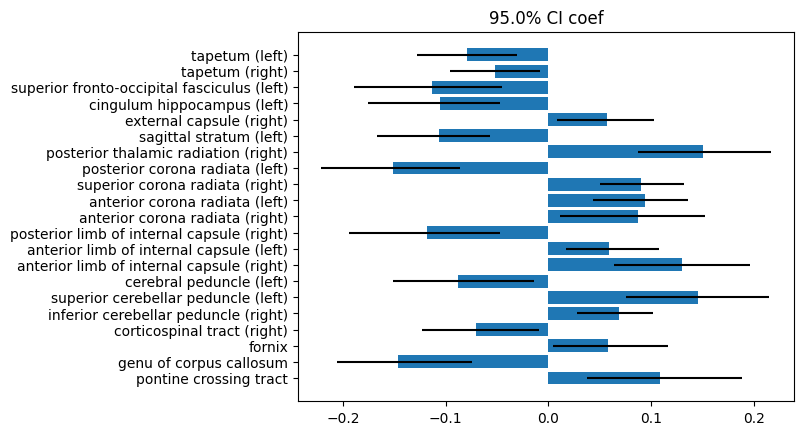

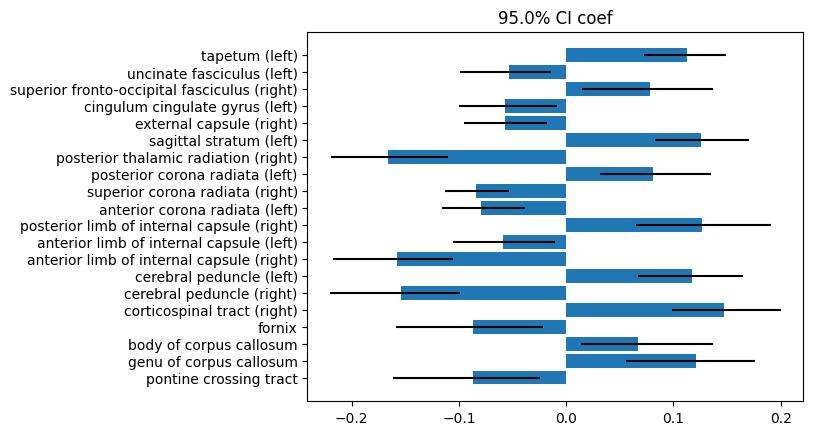

In [7]:
#----------------------------------------------------------#
#------- 使用dMRI预测high_mvpa_bmi vs low_mvpa_bmi -------#
#----------------------------------------------------------#
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# 1. 加载去混淆后的dMRI数据
df_input_dMRI = pd.read_csv(DATA_DIR + 'ukbb_dMRI_deconfounded.csv', index_col='eid')
print(f"✓ 加载去混淆dMRI数据: {df_input_dMRI.shape}")

# 2. 准备目标变量 - high_mvpa_bmi组
df_target_high = df_pa_obesity['high_mvpa_bmi_uncouple_2'].dropna()
common_index_high = df_target_high.index.intersection(df_input_dMRI.index)
print(f"\nhigh_mvpa_bmi组样本数: {len(common_index_high)}")
print(f"标签分布:\n{df_target_high.loc[common_index_high].value_counts()}")

# 3. 准备协变量（年龄和性别）
covariates_high = df_pa_obesity[['age', 'sex', 'education', 'sleep_duration', 'health_rating', 'illness_disability_infirmity', 'weight_changes']].loc[common_index_high]
print(f"协变量形状: {covariates_high.shape}")

# 4. Bootstrap LDA分析 - high_mvpa_bmi组
print("\n开始Bootstrap LDA分析 (high_mvpa_bmi组)...")
n_BS_itr = 100
alpha = 10

lda_estimator_high = calculate_feature_coef(
    df_input_dMRI.loc[common_index_high], 
    df_target_high.loc[common_index_high], 
    n_BS_itr, 
    covariates=covariates_high
)

# 5. 计算显著特征
significant_coef_high, df_coef_with_nan_high, df_coef_all_high = calculate_significant_coef(
    lda_estimator_high, dMRI_name, alpha
)

# 6. 保存结果
output_file_high = DATA_DIR + 'LDA_dMRI_high_mvpa_bmi_coef_5-95CI_all.csv'
df_coef_all_high.to_csv(output_file_high)
print(f"\n✓ high_mvpa_bmi结果已保存: {output_file_high}")
print(f"✓ 显著特征数量: {len(significant_coef_high)}")

#----------------------------------------------------------#

# 7. 准备目标变量 - low_mvpa_bmi组
df_target_low = df_pa_obesity['low_mvpa_bmi_uncouple_2'].dropna()
common_index_low = df_target_low.index.intersection(df_input_dMRI.index)
print(f"\nlow_mvpa_bmi组样本数: {len(common_index_low)}")
print(f"标签分布:\n{df_target_low.loc[common_index_low].value_counts()}")

# 8. 准备协变量
covariates_low = df_pa_obesity[['age', 'sex', 'education', 'sleep_duration', 'health_rating', 'illness_disability_infirmity', 'weight_changes']].loc[common_index_low]

# 9. Bootstrap LDA分析 - low_mvpa_bmi组
print("\n开始Bootstrap LDA分析 (low_mvpa_bmi组)...")

lda_estimator_low = calculate_feature_coef(
    df_input_dMRI.loc[common_index_low], 
    df_target_low.loc[common_index_low], 
    n_BS_itr, 
    covariates=covariates_low
)

# 10. 计算显著特征
significant_coef_low, df_coef_with_nan_low, df_coef_all_low = calculate_significant_coef(
    lda_estimator_low, dMRI_name, alpha
)

# 11. 保存结果
output_file_low = DATA_DIR + 'LDA_dMRI_low_mvpa_bmi_coef_5-95CI_all.csv'
df_coef_all_low.to_csv(output_file_low)
print(f"\n✓ low_mvpa_bmi结果已保存: {output_file_low}")
print(f"✓ 显著特征数量: {len(significant_coef_low)}")

print("\n" + "="*60)
print("dMRI分析完成!")
print("="*60)


✓ 加载去混淆rfMRI数据: (79344, 210)

high_mvpa_bmi组样本数: 15492
标签分布:
high_mvpa_bmi_uncouple_2
0.0    9078
1.0    6414
Name: count, dtype: int64
协变量形状: (15492, 7)

开始Bootstrap LDA分析 (high_mvpa_bmi组)...

✓ high_mvpa_bmi结果已保存: /home/user2/jzhang_data/Dissertation/data/LDA_rfMRI_high_mvpa_bmi_coef_5-95CI_all.csv
✓ 显著特征数量: 63

low_mvpa_bmi组样本数: 15465
标签分布:
low_mvpa_bmi_uncouple_2
0.0    8770
1.0    6695
Name: count, dtype: int64

开始Bootstrap LDA分析 (low_mvpa_bmi组)...

✓ low_mvpa_bmi结果已保存: /home/user2/jzhang_data/Dissertation/data/LDA_rfMRI_low_mvpa_bmi_coef_5-95CI_all.csv
✓ 显著特征数量: 68

rfMRI分析完成!


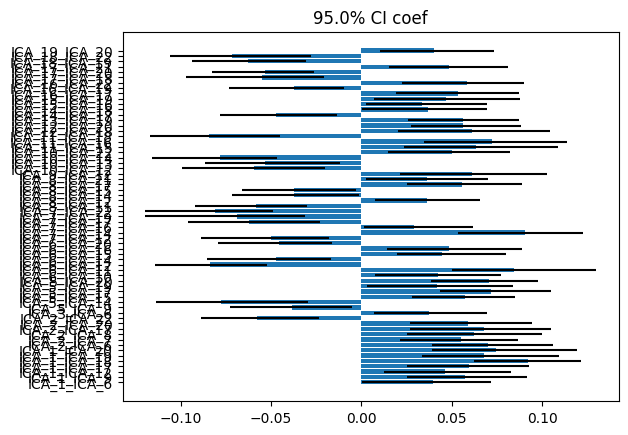

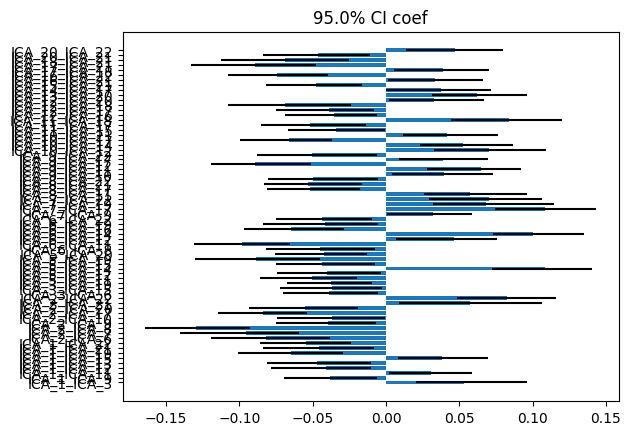

In [8]:
#----------------------------------------------------------#
#------- 使用rfMRI预测high_mvpa_bmi vs low_mvpa_bmi -------#
#----------------------------------------------------------#
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# 1. 加载去混淆后的rfMRI数据
df_input_rfMRI = pd.read_csv(DATA_DIR + 'ukbb_rfMRI_deconfounded.csv', index_col='eid')
print(f"✓ 加载去混淆rfMRI数据: {df_input_rfMRI.shape}")

# 2. 准备目标变量 - high_mvpa_bmi组
df_target_high = df_pa_obesity['high_mvpa_bmi_uncouple_2'].dropna()
common_index_high = df_target_high.index.intersection(df_input_rfMRI.index)
print(f"\nhigh_mvpa_bmi组样本数: {len(common_index_high)}")
print(f"标签分布:\n{df_target_high.loc[common_index_high].value_counts()}")

# 3. 准备协变量（年龄和性别）
covariates_high = df_pa_obesity[['age', 'sex', 'education', 'sleep_duration', 'health_rating', 'illness_disability_infirmity', 'weight_changes']].loc[common_index_high]
print(f"协变量形状: {covariates_high.shape}")

# 4. Bootstrap LDA分析 - high_mvpa_bmi组
print("\n开始Bootstrap LDA分析 (high_mvpa_bmi组)...")
n_BS_itr = 100
alpha = 10

lda_estimator_high = calculate_feature_coef(
    df_input_rfMRI.loc[common_index_high], 
    df_target_high.loc[common_index_high], 
    n_BS_itr, 
    covariates=covariates_high
)

# 5. 计算显著特征
significant_coef_high, df_coef_with_nan_high, df_coef_all_high = calculate_significant_coef(
    lda_estimator_high, rfMRI_connection_names, alpha
)

# 6. 保存结果
output_file_high = DATA_DIR + 'LDA_rfMRI_high_mvpa_bmi_coef_5-95CI_all.csv'
df_coef_all_high.to_csv(output_file_high)
print(f"\n✓ high_mvpa_bmi结果已保存: {output_file_high}")
print(f"✓ 显著特征数量: {len(significant_coef_high)}")

#----------------------------------------------------------#

# 7. 准备目标变量 - low_mvpa_bmi组
df_target_low = df_pa_obesity['low_mvpa_bmi_uncouple_2'].dropna()
common_index_low = df_target_low.index.intersection(df_input_rfMRI.index)
print(f"\nlow_mvpa_bmi组样本数: {len(common_index_low)}")
print(f"标签分布:\n{df_target_low.loc[common_index_low].value_counts()}")

# 8. 准备协变量
covariates_low = df_pa_obesity[['age', 'sex', 'education', 'sleep_duration', 'health_rating', 'illness_disability_infirmity', 'weight_changes']].loc[common_index_low]

# 9. Bootstrap LDA分析 - low_mvpa_bmi组
print("\n开始Bootstrap LDA分析 (low_mvpa_bmi组)...")

lda_estimator_low = calculate_feature_coef(
    df_input_rfMRI.loc[common_index_low], 
    df_target_low.loc[common_index_low], 
    n_BS_itr, 
    covariates=covariates_low
)

# 10. 计算显著特征
significant_coef_low, df_coef_with_nan_low, df_coef_all_low = calculate_significant_coef(
    lda_estimator_low, rfMRI_connection_names, alpha
)

# 11. 保存结果
output_file_low = DATA_DIR + 'LDA_rfMRI_low_mvpa_bmi_coef_5-95CI_all.csv'
df_coef_all_low.to_csv(output_file_low)
print(f"\n✓ low_mvpa_bmi结果已保存: {output_file_low}")
print(f"✓ 显著特征数量: {len(significant_coef_low)}")

print("\n" + "="*60)
print("rfMRI分析完成!")
print("="*60)
